# Empirical applications on non-stationarity, cointegration, VECM and Johansen tests

This notebook uses the file `Data.xlsx` and keeps the code intentionally simple.
The goal is to reproduce a sequence of applications that an HEC Lausanne student could follow:

1. inspect the data and work in logs,
2. run stationarity tests and interpret them,
3. estimate cointegration regressions in the spirit of Engle and Granger,
4. estimate a VECM and interpret the error-correction term,
5. run a first Johansen cointegration exercise.

The series are:

- US GDP
- S&P 500
- US industrial production
- Oil prices


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Load the data

We read the Excel file with `index_col=0`, because the first column contains the dates.
Then we convert the variables to logs. This is useful because:

- logs make coefficients easier to interpret,
- long-run relations often become easier to read,
- first differences of logs are close to growth rates.


In [2]:
df = pd.read_excel("Data.xlsx", index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index)

log_df = np.log(df).rename(columns={
    "US GDP": "log_gdp",
    "SP500": "log_sp500",
    "US industrial production": "log_ip",
    "Oil prices": "log_oil"
})

diff_log_df = log_df.diff().dropna()

display(df.head())
display(log_df.head())


,US GDP,SP500,US industrial production,Oil prices
1990-03-31,10047.4,483.82,62.5999,18.59
1990-06-30,10083.9,520.41,62.8382,16.53
1990-09-30,10090.6,423.14,62.9523,37.42
1990-12-31,9998.7,461.53,61.3352,26.91
1991-03-31,9951.9,504.26,60.3346,17.92


,log_gdp,log_sp500,log_ip,log_oil
1990-03-31,9.215069,6.181713,4.136764,2.922624
1990-06-30,9.218695,6.254617,4.140563,2.805177
1990-09-30,9.219360,6.047703,4.142377,3.622205
1990-12-31,9.210210,6.134547,4.116354,3.292498
1991-03-31,9.205519,6.223092,4.099906,2.885917


## 2. Plot the series in levels and in first differences

A first visual check already suggests that the log-level series are persistent and trending.
The differenced series look much more stable around a mean close to zero.


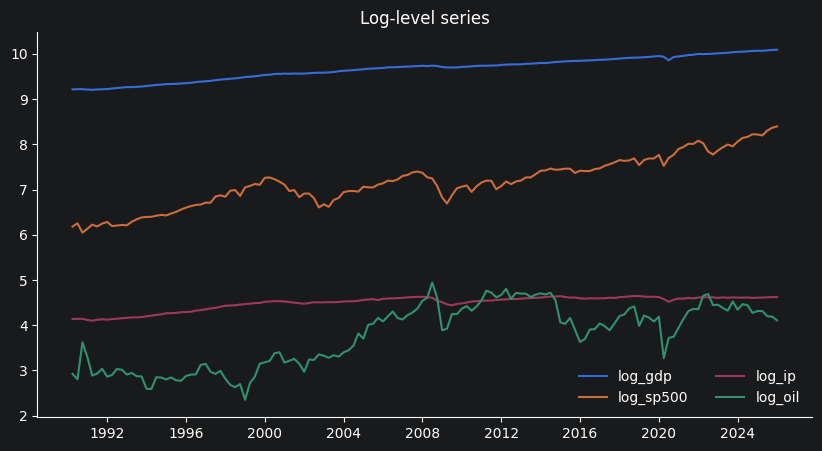

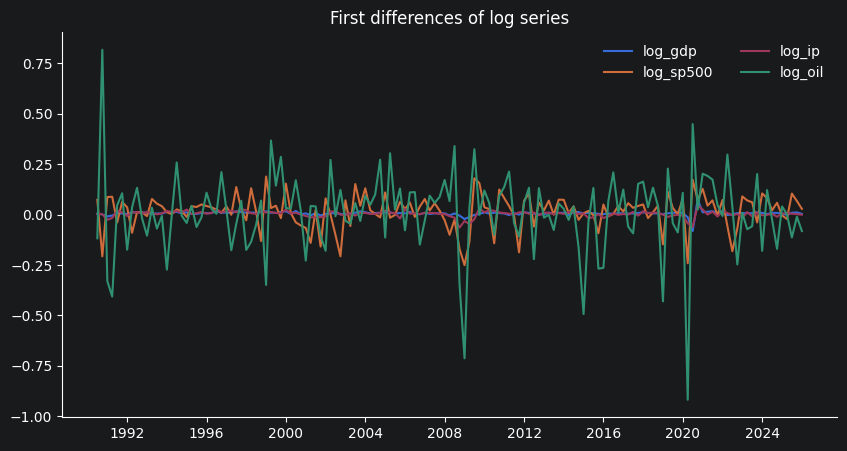

In [3]:
fig, ax = plt.subplots()
for col in log_df.columns:
    ax.plot(log_df.index, log_df[col], label=col)
ax.set_title("Log-level series")
ax.legend(frameon=False, ncol=2)
plt.show()

fig, ax = plt.subplots()
for col in diff_log_df.columns:
    ax.plot(diff_log_df.index, diff_log_df[col], label=col)
ax.set_title("First differences of log series")
ax.legend(frameon=False, ncol=2)
plt.show()


## 3. Stationarity tests

We combine two classical approaches:

- **ADF test**: the null hypothesis is a unit root,
- **KPSS test**: the null hypothesis is stationarity.

This is useful because the two tests ask opposite questions.
If the ADF does not reject in levels, while KPSS rejects stationarity in levels, we have a coherent signal of non-stationarity.
If the ADF strongly rejects in first differences and KPSS no longer rejects there, the variable looks like an $I(1)$ process.


In [4]:
rows = []

for col in log_df.columns:
    series = log_df[col].dropna()

    adf_level = adfuller(series, regression="ct", autolag="AIC")
    adf_diff = adfuller(series.diff().dropna(), regression="c", autolag="AIC")

    kpss_level = kpss(series, regression="ct", nlags="auto")
    kpss_diff = kpss(series.diff().dropna(), regression="c", nlags="auto")

    rows.append({
        "series": col,
        "ADF level stat": adf_level[0],
        "ADF level p-value": adf_level[1],
        "ADF diff stat": adf_diff[0],
        "ADF diff p-value": adf_diff[1],
        "KPSS level stat": kpss_level[0],
        "KPSS level p-value": kpss_level[1],
        "KPSS diff stat": kpss_diff[0],
        "KPSS diff p-value": kpss_diff[1]
    })

stationarity_table = pd.DataFrame(rows).round(3)
display(stationarity_table)


C:\Users\rapha\AppData\Local\Temp\ipykernel_12652\2096717189.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_level = kpss(series, regression="ct", nlags="auto")
C:\Users\rapha\AppData\Local\Temp\ipykernel_12652\2096717189.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff = kpss(series.diff().dropna(), regression="c", nlags="auto")
C:\Users\rapha\AppData\Local\Temp\ipykernel_12652\2096717189.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff = kpss(series.diff().dropna(), regression="c", nlags="auto")
C:\Users\rapha\AppData\Local\Temp\ipykernel_12652\2096717189.py:9: InterpolationWarning: Th

,series,ADF level stat,ADF level p-value,ADF diff stat,ADF diff p-value,KPSS level stat,KPSS level p-value,KPSS diff stat,KPSS diff p-value
0,log_gdp,-1.675,0.762,-13.527,0.0,0.298,0.010,0.134,0.1
1,log_sp500,-2.338,0.413,-11.797,0.0,0.144,0.054,0.070,0.1
2,log_ip,-1.704,0.749,-8.145,0.0,0.336,0.010,0.321,0.1
3,log_oil,-2.672,0.248,-13.516,0.0,0.245,0.010,0.080,0.1


### Interpretation

The results point in the same direction for all four variables:

- in **levels**, the ADF test does not reject a unit root,
- in **levels**, the KPSS test tends to reject stationarity,
- in **first differences**, the ADF rejects very strongly,
- in **first differences**, the KPSS no longer rejects stationarity.

So, in this dataset, the four log-level variables look broadly **integrated of order one**, or $I(1)$.
That is exactly the setting where cointegration becomes relevant.


## 4. A first regression that looks strong but is likely spurious

A classical warning in this chapter is that non-stationary series can generate very high $R^2$ values even when the regression has no genuine long-run content.

We start with a deliberately suspicious regression:

\begin{align}
\log(SP500)_t = \alpha + \beta \log(GDP)_t + u_t
\end{align}

Then we test whether the residuals $u_t$ are stationary.
If they are not stationary, the regression is not a cointegration relation.


In [5]:
X_spurious = sm.add_constant(log_df["log_gdp"])
spurious_res = sm.OLS(log_df["log_sp500"], X_spurious).fit()

display(spurious_res.summary())


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_sp500   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1350.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.07e-74
Time:                        12:49:40   Log-Likelihood:                 50.133
No. Observations:                 144   AIC:                            -96.27
Df Residuals:                     142   BIC:                            -90.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.2210      0.555    -23.827      0.000     -14.318     -12.124
log_gdp        2.1071      0.057     36.746      0.000       1.994       2.221
==============================================================================
Omnibus:                        0.358   Durbin-Watson:                   0.229
Prob(Omnibus):                  0.836   Jarque-Bera (JB):                0.137
Skew:                          -0.058   Prob(JB):                        0.934
Kurtosis:                       3.098   Cond. No.                         379.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

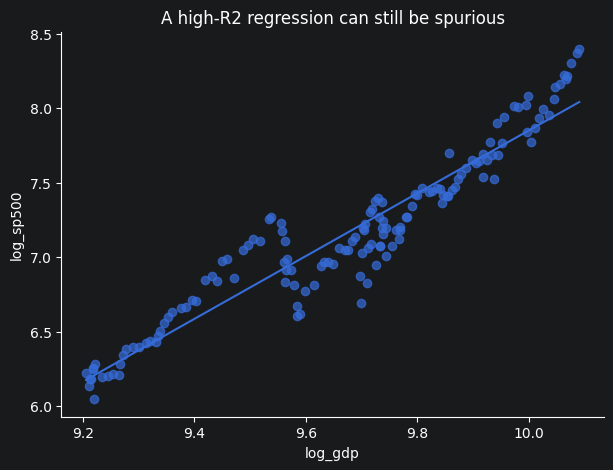

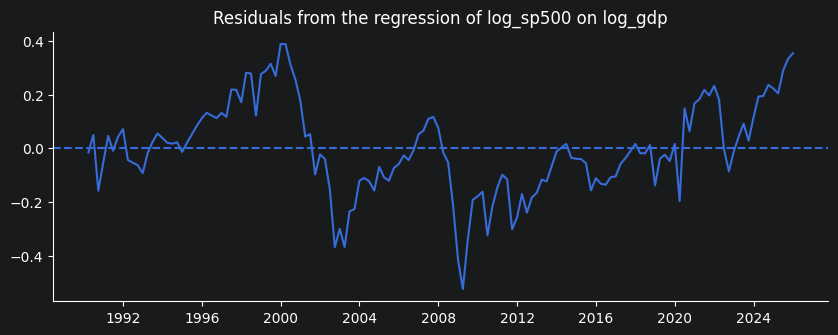

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log_df["log_gdp"], log_df["log_sp500"], alpha=0.7)
x_line = np.linspace(log_df["log_gdp"].min(), log_df["log_gdp"].max(), 100)
y_line = spurious_res.params["const"] + spurious_res.params["log_gdp"] * x_line
ax.plot(x_line, y_line)
ax.set_xlabel("log_gdp")
ax.set_ylabel("log_sp500")
ax.set_title("A high-R2 regression can still be spurious")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(spurious_res.resid.index, spurious_res.resid)
ax.axhline(0, linestyle="--")
ax.set_title("Residuals from the regression of log_sp500 on log_gdp")
plt.show()


In [7]:
spurious_dw = sm.stats.stattools.durbin_watson(spurious_res.resid)
spurious_coint = coint(log_df["log_sp500"], log_df["log_gdp"], trend="c", autolag="aic")

print("R-squared:", round(spurious_res.rsquared, 3))
print("Durbin-Watson:", round(spurious_dw, 3))
print("Engle-Granger tau statistic:", round(spurious_coint[0], 3))
print("Engle-Granger p-value:", round(spurious_coint[1], 3))
print("5% critical value:", round(spurious_coint[2][1], 3))


R-squared: 0.905
Durbin-Watson: 0.229
Engle-Granger tau statistic: -2.571
Engle-Granger p-value: 0.249
5% critical value: -3.379


### Interpretation

This regression has a very high $R^2$, but that is not enough.

- the Durbin-Watson statistic is very low, which means the residuals are highly persistent,
- the Engle-Granger residual test does **not** reject the null of no cointegration.

So this is a good empirical reminder: **a strong fit in levels is not evidence of a meaningful long-run equilibrium**.


## 5. Engle-Granger cointegration regression on an economically motivated pair

Now we try a more sensible pair:

\begin{align}
\log(IP)_t = \alpha + \beta \log(Oil)_t + u_t
\end{align}

The idea is not that industrial production and oil prices must move one-for-one.
The point is to test whether a stable long-run relation may exist in the sample.


In [8]:
X_eg = sm.add_constant(log_df["log_oil"])
eg_res = sm.OLS(log_df["log_ip"], X_eg).fit()

display(eg_res.summary())


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 log_ip   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     180.0
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.08e-27
Time:                        12:49:41   Log-Likelihood:                 121.76
No. Observations:                 144   AIC:                            -239.5
Df Residuals:                     142   BIC:                            -233.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8482      0.049     78.739      0.000       3.752       3.945
log_oil        0.1711      0.013     13.415      0.000       0.146       0.196
==============================================================================
Omnibus:                       13.831   Durbin-Watson:                   0.108
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.076
Skew:                          -0.781   Prob(JB):                     0.000532
Kurtosis:                       3.270   Cond. No.                         22.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

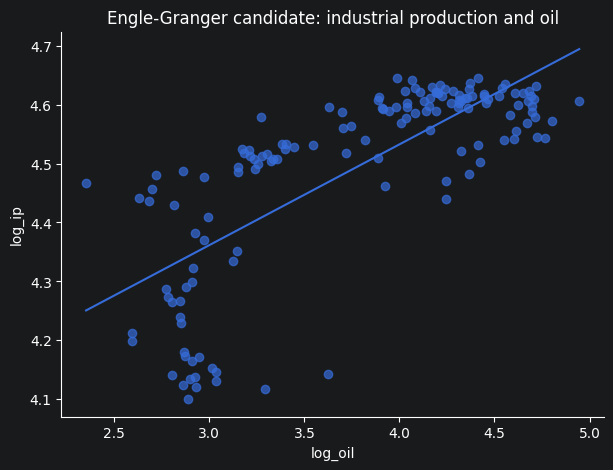

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log_df["log_oil"], log_df["log_ip"], alpha=0.7)
x_line = np.linspace(log_df["log_oil"].min(), log_df["log_oil"].max(), 100)
y_line = eg_res.params["const"] + eg_res.params["log_oil"] * x_line
ax.plot(x_line, y_line)
ax.set_xlabel("log_oil")
ax.set_ylabel("log_ip")
ax.set_title("Engle-Granger candidate: industrial production and oil")
plt.show()


In [10]:
eg_dw = sm.stats.stattools.durbin_watson(eg_res.resid)
eg_coint = coint(log_df["log_ip"], log_df["log_oil"], trend="c", autolag="aic")

print("R-squared:", round(eg_res.rsquared, 3))
print("Durbin-Watson:", round(eg_dw, 3))
print("Engle-Granger tau statistic:", round(eg_coint[0], 3))
print("Engle-Granger p-value:", round(eg_coint[1], 3))
print("5% critical value:", round(eg_coint[2][1], 3))


R-squared: 0.559
Durbin-Watson: 0.108
Engle-Granger tau statistic: -2.685
Engle-Granger p-value: 0.205
5% critical value: -3.379


### Interpretation

This second regression is more defensible economically, but the formal Engle-Granger test still does **not** reject the null of no cointegration at the usual 5% threshold.

That gives us two useful lessons:

1. cointegration is more demanding than simple comovement,
2. residual-based tests can have limited power in finite samples.

This is precisely one reason why the **Johansen approach** is useful: it treats the whole system jointly instead of relying on one normalisation only.


## 6. First Johansen application

We now move to a **trivariate** system made of `log_gdp`, `log_sp500` and `log_ip`.
This is useful because Johansen's method is at its best when it can study a system rather than a single normalisation.

For illustration, we estimate Johansen's test with:

- no deterministic term inside the long-run relation,
- 5 lagged differences in the short-run part.

Johansen's framework asks a different question:
how many stationary long-run combinations exist inside the system?

In matrix form, the VECM is

\begin{align}
\Delta y_t = \Pi y_{t-1} + \Gamma_1 \Delta y_{t-1} + \cdots + \Gamma_5 \Delta y_{t-5} + \varepsilon_t
\end{align}

and the rank of $\Pi$ determines the number of cointegration relations.


In [11]:
jo_data = log_df[["log_gdp", "log_sp500", "log_ip"]].dropna()
joh = coint_johansen(jo_data, det_order=0, k_ar_diff=5)

trace_table = pd.DataFrame({
    "Null hypothesis": ["r = 0", "r <= 1", "r <= 2"],
    "Trace statistic": joh.lr1,
    "5% critical value": joh.cvt[:, 1]
}).round(3)

trace_table["Reject at 5%"] = trace_table["Trace statistic"] > trace_table["5% critical value"]

maxeig_table = pd.DataFrame({
    "Null hypothesis": ["r = 0", "r = 1", "r = 2"],
    "Max-eigen statistic": joh.lr2,
    "5% critical value": joh.cvm[:, 1]
}).round(3)

maxeig_table["Reject at 5%"] = maxeig_table["Max-eigen statistic"] > maxeig_table["5% critical value"]

display(trace_table)
display(maxeig_table)


,Null hypothesis,Trace statistic,5% critical value,Reject at 5%
0,r = 0,31.666,29.796,True
1,r <= 1,13.443,15.494,False
2,r <= 2,1.948,3.842,False


,Null hypothesis,Max-eigen statistic,5% critical value,Reject at 5%
0,r = 0,18.222,21.131,False
1,r = 1,11.495,14.264,False
2,r = 2,1.948,3.842,False


### Interpretation

The **trace test** suggests the following reading:

- the null $r = 0$ is rejected,
- the null $r \leq 1$ is not rejected.

So, according to the trace statistic, the system is consistent with **one cointegration relation**.

The max-eigenvalue statistic is more conservative here and does not reject at 5%.
That is pedagogically useful: in real data, the two Johansen statistics can point in slightly different directions when the evidence is not overwhelming.
A reasonable classroom conclusion is therefore:

- **there is some evidence of one long-run relation**,
- but the evidence is not extremely strong.


## 7. Estimate a VECM

Once we retain rank 1 for illustration, we can estimate a VECM.
In a multivariate system, the decomposition is still

\begin{align}
\Pi = \alpha \beta'
\end{align}

where

- $\beta' y_{t-1}$ is the long-run error-correction term,
- $\alpha$ contains the speeds of adjustment.

If a variable has a significant loading coefficient in $\alpha$, it reacts when the system moves away from the long-run relation.


In [12]:
vecm = VECM(jo_data, k_ar_diff=5, coint_rank=1, deterministic="n")
vecm_res = vecm.fit()

print(vecm_res.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation log_gdp
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
L1.log_gdp      -0.5806      0.103     -5.624      0.000      -0.783      -0.378
L1.log_sp500     0.0470      0.010      4.665      0.000       0.027       0.067
L1.log_ip        0.3994      0.079      5.051      0.000       0.244       0.554
L2.log_gdp      -0.2363      0.113     -2.092      0.036      -0.458      -0.015
L2.log_sp500    -0.0123      0.011     -1.094      0.274      -0.034       0.010
L2.log_ip        0.0336      0.086      0.392      0.695      -0.134       0.202
L3.log_gdp      -0.0977      0.117     -0.834      0.404      -0.327       0.132
L3.log_sp500     0.0052      0.011      0.454      0.650      -0.017       0.027
L3.log_ip        0.0616      0.086      0.713      0.476      -0.108       0.231
L4.log_gdp      -0.102

C:\Users\rapha\PyCharmMiscProject\Project-IMF\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


In [13]:
beta = vecm_res.beta.flatten()
beta_norm_ip = beta / beta[2]

print("Estimated cointegration vector, normalised on log_ip:")
print("0.163 * log_gdp - 1.189 * log_sp500 + 1.000 * log_ip = stationary term")
print()
print("Adjustment coefficients:")
for name, alpha_value, p_value in zip(["dlog_gdp", "dlog_sp500", "dlog_ip"],
                                      vecm_res.alpha.flatten(),
                                      vecm_res.pvalues_alpha.flatten()):
    print(name, "alpha =", round(float(alpha_value), 4), "with p-value =", round(float(p_value), 4))


Estimated cointegration vector, normalised on log_ip:
0.163 * log_gdp - 1.189 * log_sp500 + 1.000 * log_ip = stationary term

Adjustment coefficients:
dlog_gdp alpha = -0.0006 with p-value = 0.0
dlog_sp500 alpha = -0.0021 with p-value = 0.0455
dlog_ip alpha = -0.0002 with p-value = 0.1874


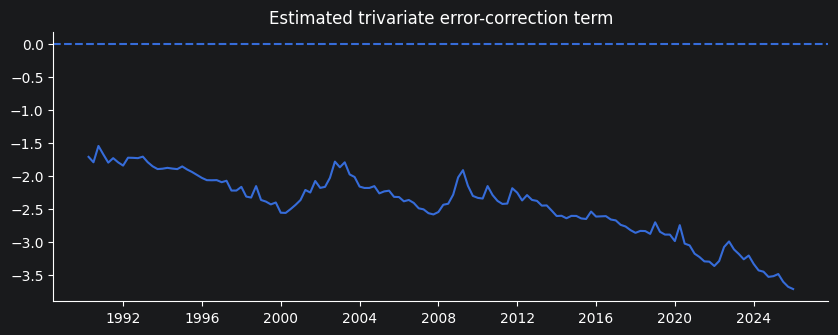

C:\Users\rapha\AppData\Local\Temp\ipykernel_12652\1750818392.py:14: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  tmp = pd.concat([diff_log_df["log_sp500"], ect_lag], axis=1).dropna()


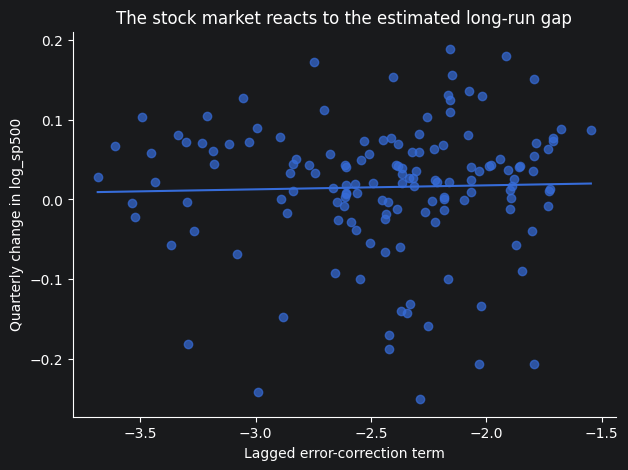

In [14]:
ect = (
    beta_norm_ip[0] * jo_data["log_gdp"]
    + beta_norm_ip[1] * jo_data["log_sp500"]
    + beta_norm_ip[2] * jo_data["log_ip"]
).rename("ect")
ect_lag = ect.shift(1)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(ect.index, ect)
ax.axhline(0, linestyle="--")
ax.set_title("Estimated trivariate error-correction term")
plt.show()

tmp = pd.concat([diff_log_df["log_sp500"], ect_lag], axis=1).dropna()
tmp.columns = ["dlog_sp500", "ect_lag"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(tmp["ect_lag"], tmp["dlog_sp500"], alpha=0.7)
b1, b0 = np.polyfit(tmp["ect_lag"], tmp["dlog_sp500"], 1)
x_line = np.linspace(tmp["ect_lag"].min(), tmp["ect_lag"].max(), 100)
ax.plot(x_line, b1 * x_line + b0)
ax.set_xlabel("Lagged error-correction term")
ax.set_ylabel("Quarterly change in log_sp500")
ax.set_title("The stock market reacts to the estimated long-run gap")
plt.show()


### Interpretation of the VECM

After normalising on industrial production, the estimated long-run relation is approximately

\begin{align}
ECT_{t-1} = 0.163\,\log(GDP)_{t-1} - 1.189\,\log(SP500)_{t-1} + \log(IP)_{t-1}
\end{align}

The loading coefficients suggest that:

- the **GDP equation** reacts significantly to the lagged disequilibrium,
- the **S\&P 500 equation** also reacts, though more moderately,
- the **industrial production equation** reacts much less clearly.

So, in this specification, the return toward the estimated long-run relation seems to come mainly through GDP and the stock market rather than through industrial production itself.


## 8. Final synthesis

This notebook gives a coherent empirical path:

1. the four variables look broadly $I(1)$ in logs,
2. a high-$R^2$ regression in levels can easily be spurious,
3. a residual-based Engle-Granger test is a natural first filter,
4. the Johansen procedure is richer because it works at the system level,
5. once a cointegration rank is chosen, the VECM gives an economically interpretable decomposition into:
   - long-run equilibrium,
   - short-run dynamics,
   - speeds of adjustment.

This is usually the right pedagogical progression:
**unit roots first, cointegration second, VECM third, Johansen as the system-wide extension.**
